<a href="https://colab.research.google.com/github/danieligelnik/CCFraudProject/blob/main/Data_manipulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# Install dependencies as needed:
%pip install kagglehub[pandas-datasets]

In [24]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays as hol
from sklearn.model_selection import train_test_split

In [25]:
def load_kagglehub_dataset(dataset_path, file_name):
  # Load the latest version
  return kagglehub.dataset_load(
      KaggleDatasetAdapter.PANDAS,
      dataset_path,
      file_name,
      # Provide any additional arguments like
      # sql_query or pandas_kwargs. See the
      # documenation for more information:
      # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
      )

In [26]:
def df_info(df, what):
  if (what == "head"):
    print("First 5 records:")
    with pd.option_context('display.max_columns', 50):
      display(df.head())
  elif (what == "columns"):
    print("Columns:")
    display(df.columns)
    print(f"Rows / columns: {df.shape}")
  elif (what == "info"):
    print("Missing values:")
    display(df.isna().sum())
    display(df.info())

# **Data**

In [27]:
# Set the path to the file you'd like to load
credit_cards_path_train = "fraudTrain.csv"
main_path="dermisfit/fraud-transactions-dataset"

# Load the latest version
df_cards_train = load_kagglehub_dataset(main_path, credit_cards_path_train)

Using Colab cache for faster access to the 'fraud-transactions-dataset' dataset.


In [28]:
df_cards_valid = train_test_split(df_cards_train, test_size=0.2, random_state=42)[1]
df_cards_valid.head(5)



,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1045211,1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,...,40.6153,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0
547406,547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,...,42.8250,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0
110142,110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,...,39.9636,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0
1285953,1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,...,42.9580,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0
271705,271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,...,41.6423,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0


**Data encoding**

In [29]:
df_cards_train['gender'] = df_cards_train['gender'].map({'F': 1, 'M': 0})
df_cards_valid['gender'] = df_cards_valid['gender'].map({'F': 1, 'M': 0})

In [30]:
df_cards_train = pd.get_dummies(df_cards_train, columns=['category'], prefix='category', drop_first=True)
df_cards_valid = pd.get_dummies(df_cards_valid, columns=['category'], prefix='category', drop_first=True)

# The 'category' column is already replaced by get_dummies, so dropping it again is redundant and causes an error.

In [31]:
df_cards_train['trans_date_trans_time'] = pd.to_datetime(df_cards_train['trans_date_trans_time'])
df_cards_valid['trans_date_trans_time'] = pd.to_datetime(df_cards_valid['trans_date_trans_time'])


In [32]:
df_cards_train['is_weekend'] = df_cards_train['trans_date_trans_time'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
df_cards_valid['is_weekend'] = df_cards_valid['trans_date_trans_time'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

**Feature engineering**

In [33]:
#adding new column of age calculated from dob and trans_date_trans_time
# age at the moment of the transaction

df_cards_train['age'] = (df_cards_train['trans_date_trans_time'] - pd.to_datetime(df_cards_train.dob)).dt.days
df_cards_valid['age'] = (df_cards_valid['trans_date_trans_time'] - pd.to_datetime(df_cards_valid.dob)).dt.days

**Dropping columns**

In [34]:
df_cards_train = df_cards_train.drop(columns=['Unnamed: 0','cc_num','merchant','first','last','street','zip','lat','long','job','trans_num','unix_time','merch_lat','merch_long', 'trans_date_trans_time', 'dob', 'city', 'state'])
df_cards_valid = df_cards_valid.drop(columns=['Unnamed: 0','cc_num','merchant','first','last','street','zip','lat','long','job','trans_num','unix_time','merch_lat','merch_long', 'trans_date_trans_time', 'dob', 'city', 'state'])

**Imbalance treatment**

In [35]:
from sklearn.utils import class_weight

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_cards_train['is_fraud']),
    y=df_cards_train['is_fraud']
)
class_weights_dict = dict(zip(np.unique(df_cards_train['is_fraud']), class_weights))

print("Class weights for 'is_fraud' column:")
print(class_weights_dict)
df_cards_train['is_fraud'].value_counts()


Class weights for 'is_fraud' column:
{np.int64(0): np.float64(0.5029111776656126), np.int64(1): np.float64(86.37589928057554)}


,count
is_fraud,
0,1289169
1,7506


### Logistic Regression Model with Class Weights

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Separate features (X) and target (y) for training data
X_train = df_cards_train.drop('is_fraud', axis=1)
y_train = df_cards_train['is_fraud']

# Separate features (X) and target (y) for validation data
X_valid = df_cards_valid.drop('is_fraud', axis=1)
y_valid = df_cards_valid['is_fraud']

# Initialize Logistic Regression model with class weights
# Using 'liblinear' solver for smaller datasets and when class_weight is used
# 'saga' is also an option for multiclass and L1/L2 regularization
log_reg_model = LogisticRegression(
    solver='liblinear',
    class_weight=class_weights_dict,
    random_state=42,
    n_jobs=-1
)

# Train the model
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained with class weights.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression model trained with class weights.


## LinearSVC Model with scaler

Training Support Vector Machine model with class weights (via LinearSVC and CalibratedClassifierCV)... This might take a while.
Support Vector Machine model trained with class weights.

Classification Report on Validation Set (SVM):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257815
           1       0.00      0.00      0.00      1520

    accuracy                           0.99    259335
   macro avg       0.50      0.50      0.50    259335
weighted avg       0.99      0.99      0.99    259335


Confusion Matrix on Validation Set (SVM):


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Predicted 0,Predicted 1
Actual 0,257815,0
Actual 1,1520,0



ROC AUC Score on Validation Set (SVM): 0.9187


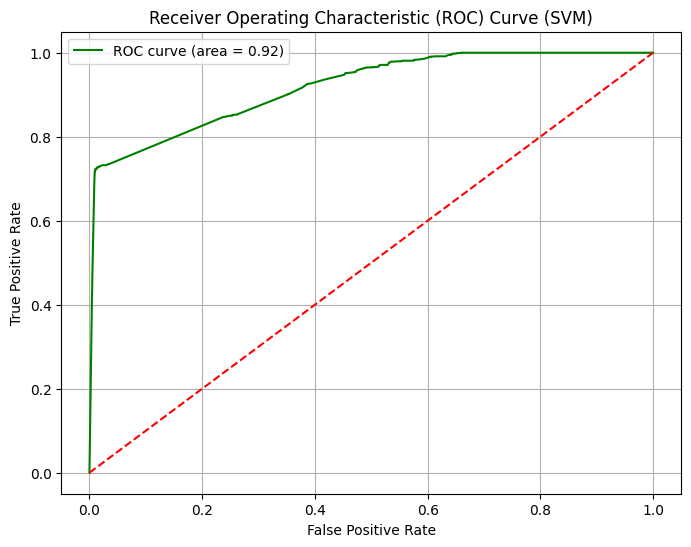

In [37]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

# Assume X_train, y_train, X_valid, y_valid, class_weights_dict are already defined from previous cells.

# 1. Scale the features - crucial for SVMs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# 2. Initialize LinearSVC model with class weights
# LinearSVC does not directly support 'predict_proba', so we wrap it with CalibratedClassifierCV
# Using dual=False is recommended when n_samples > n_features for a large number of samples
linear_svm = LinearSVC(class_weight=class_weights_dict, random_state=42, dual=False, max_iter=1000)

# 3. Calibrate the classifier to get probability estimates
# Using 'isotonic' method for calibration, 'cv=5' for cross-validation splits
svm_model = CalibratedClassifierCV(linear_svm, method='isotonic', cv=5)

print("Training Support Vector Machine model with class weights (via LinearSVC and CalibratedClassifierCV)... This might take a while.")

# Train the model
svm_model.fit(X_train_scaled, y_train)

print("Support Vector Machine model trained with class weights.")

# Make predictions on the scaled validation set
y_pred_svm = svm_model.predict(X_valid_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_valid_scaled)[:, 1]

# Print classification report
print("\nClassification Report on Validation Set (SVM):")
print(classification_report(y_valid, y_pred_svm))

# Print Confusion Matrix
print("\nConfusion Matrix on Validation Set (SVM):")
conf_matrix_svm = confusion_matrix(y_valid, y_pred_svm)
display(pd.DataFrame(conf_matrix_svm,
                     index=['Actual 0', 'Actual 1'],
                     columns=['Predicted 0', 'Predicted 1']))

# Calculate and print ROC AUC score
roc_auc_svm = roc_auc_score(y_valid, y_pred_proba_svm)
print(f"\nROC AUC Score on Validation Set (SVM): {roc_auc_svm:.4f}")

# Plot ROC curve
fpr_svm, tpr_svm, _ = roc_curve(y_valid, y_pred_proba_svm)
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='green', label=f'ROC curve (area = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (SVM)')
plt.legend()
plt.grid(True)
plt.show()

### Gradient Boosting Classifier Model with Class Weights

Training Gradient Boosting Classifier model with sample weights... This might take a while.
Gradient Boosting Classifier model trained with sample weights.

Classification Report on Validation Set (Gradient Boosting):
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    257815
           1       0.12      0.94      0.21      1520

    accuracy                           0.96    259335
   macro avg       0.56      0.95      0.59    259335
weighted avg       0.99      0.96      0.97    259335


Confusion Matrix on Validation Set (Gradient Boosting):


,Predicted 0,Predicted 1
Actual 0,246924,10891
Actual 1,85,1435



ROC AUC Score on Validation Set (Gradient Boosting): 0.9922


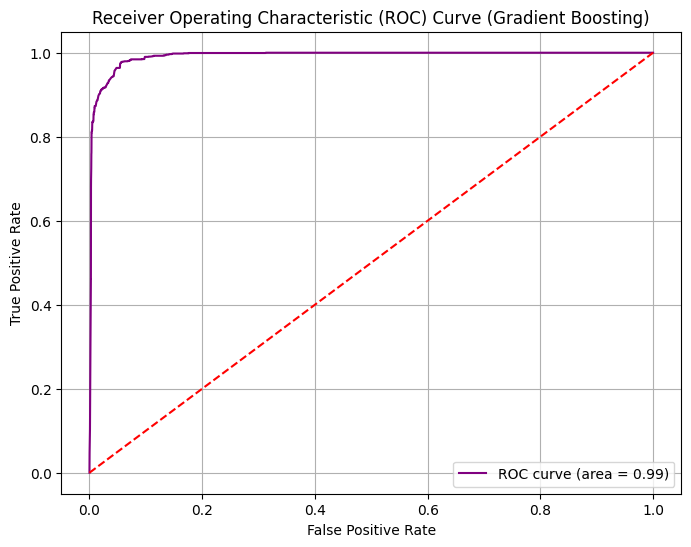

In [38]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# The features X_train_scaled, y_train, X_valid_scaled, y_valid, and class_weights_dict
# are assumed to be defined from previous cells.

# Create sample weights for GradientBoostingClassifier
# GradientBoostingClassifier doesn't directly support 'class_weight' parameter in its constructor.
# Instead, we pass 'sample_weight' to the fit method.
sample_weights_gbc = np.array([class_weights_dict[label] for label in y_train])

# Initialize Gradient Boosting Classifier model
gbc_model = GradientBoostingClassifier(
    n_estimators=100,  # Number of boosting stages to perform
    learning_rate=0.1, # Shrinkage factor applied to the contribution of each tree
    max_depth=3,       # Maximum depth of the individual regression estimators
    random_state=42
)

print("Training Gradient Boosting Classifier model with sample weights... This might take a while.")

# Train the model with sample weights
gbc_model.fit(X_train_scaled, y_train, sample_weight=sample_weights_gbc)

print("Gradient Boosting Classifier model trained with sample weights.")

# Make predictions on the scaled validation set
y_pred_gbc = gbc_model.predict(X_valid_scaled)
y_pred_proba_gbc = gbc_model.predict_proba(X_valid_scaled)[:, 1]

# Print classification report
print("\nClassification Report on Validation Set (Gradient Boosting):")
print(classification_report(y_valid, y_pred_gbc))

# Print Confusion Matrix
print("\nConfusion Matrix on Validation Set (Gradient Boosting):")
conf_matrix_gbc = confusion_matrix(y_valid, y_pred_gbc)
display(pd.DataFrame(conf_matrix_gbc,
                     index=['Actual 0', 'Actual 1'],
                     columns=['Predicted 0', 'Predicted 1']))

# Calculate and print ROC AUC score
roc_auc_gbc = roc_auc_score(y_valid, y_pred_proba_gbc)
print(f"\nROC AUC Score on Validation Set (Gradient Boosting): {roc_auc_gbc:.4f}")

# Plot ROC curve
fpr_gbc, tpr_gbc, _ = roc_curve(y_valid, y_pred_proba_gbc)
plt.figure(figsize=(8, 6))
plt.plot(fpr_gbc, tpr_gbc, color='purple', label=f'ROC curve (area = {roc_auc_gbc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Gradient Boosting)')
plt.legend()
plt.grid(True)
plt.show()

### XGBoost Classifier Model

Training XGBoost model... This might take a while.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:17:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained.

Classification Report on Validation Set (XGBoost):
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    257815
           1       0.12      0.96      0.22      1520

    accuracy                           0.96    259335
   macro avg       0.56      0.96      0.60    259335
weighted avg       0.99      0.96      0.97    259335


Confusion Matrix on Validation Set (XGBoost):


,Predicted 0,Predicted 1
Actual 0,247360,10455
Actual 1,65,1455



ROC AUC Score on Validation Set (XGBoost): 0.9922


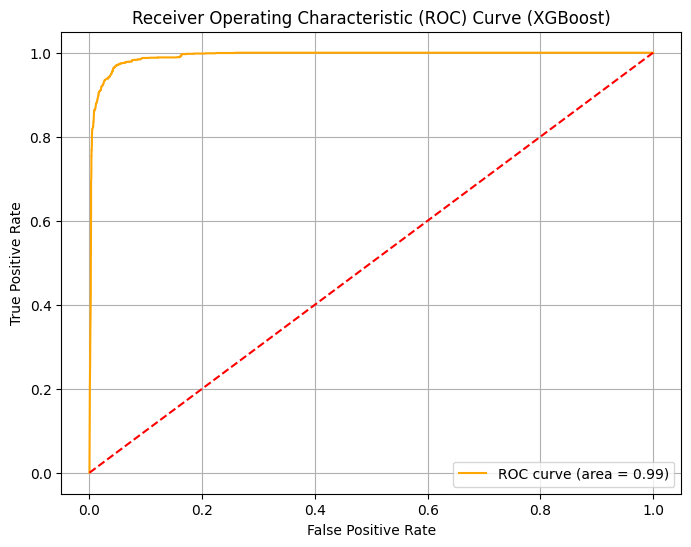

In [39]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for XGBoost (sum of negative instances / sum of positive instances)
# This is the standard way XGBoost handles class imbalance
negative_cases = np.sum(y_train == 0)
positive_cases = np.sum(y_train == 1)
scale_weight = negative_cases / positive_cases

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    scale_pos_weight=scale_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("Training XGBoost model... This might take a while.")

# Train the model
xgb_model.fit(X_train_scaled, y_train)

print("XGBoost model trained.")

# Make predictions on the scaled validation set
y_pred_xgb = xgb_model.predict(X_valid_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_valid_scaled)[:, 1]

# Print classification report
print("\nClassification Report on Validation Set (XGBoost):")
print(classification_report(y_valid, y_pred_xgb))

# Print Confusion Matrix
print("\nConfusion Matrix on Validation Set (XGBoost):")
conf_matrix_xgb = confusion_matrix(y_valid, y_pred_xgb)
display(pd.DataFrame(conf_matrix_xgb,
                     index=['Actual 0', 'Actual 1'],
                     columns=['Predicted 0', 'Predicted 1']))

# Calculate and print ROC AUC score
roc_auc_xgb = roc_auc_score(y_valid, y_pred_proba_xgb)
print(f"\nROC AUC Score on Validation Set (XGBoost): {roc_auc_xgb:.4f}")

# Plot ROC curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_valid, y_pred_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='orange', label=f'ROC curve (area = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (XGBoost)')
plt.legend()
plt.grid(True)
plt.show()

### AdaBoost Classifier Model with Class Weights

Training AdaBoost Classifier model... This might take a while.
AdaBoost model trained.

Classification Report (AdaBoost):
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    257815
           1       0.09      0.87      0.17      1520

    accuracy                           0.95    259335
   macro avg       0.55      0.91      0.57    259335
weighted avg       0.99      0.95      0.97    259335


Confusion Matrix (AdaBoost):


,Predicted 0,Predicted 1
Actual 0,244662,13153
Actual 1,193,1327



ROC AUC Score (AdaBoost): 0.9701


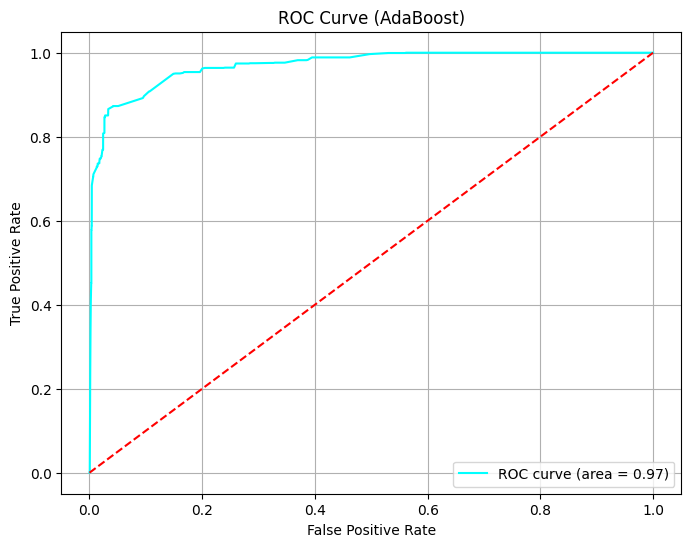

In [40]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Create sample weights for AdaBoost based on class imbalance
sample_weights_ada = np.array([class_weights_dict[label] for label in y_train])

# Initialize AdaBoost Classifier
# Using the default DecisionTreeClassifier as base estimator
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

print("Training AdaBoost Classifier model... This might take a while.")

# Train the model with sample weights
ada_model.fit(X_train_scaled, y_train, sample_weight=sample_weights_ada)

print("AdaBoost model trained.")

# Make predictions on the scaled validation set
y_pred_ada = ada_model.predict(X_valid_scaled)
y_pred_proba_ada = ada_model.predict_proba(X_valid_scaled)[:, 1]

# Evaluation
print("\nClassification Report (AdaBoost):")
print(classification_report(y_valid, y_pred_ada))

print("\nConfusion Matrix (AdaBoost):")
conf_matrix_ada = confusion_matrix(y_valid, y_pred_ada)
display(pd.DataFrame(conf_matrix_ada,
                     index=['Actual 0', 'Actual 1'],
                     columns=['Predicted 0', 'Predicted 1']))

roc_auc_ada = roc_auc_score(y_valid, y_pred_proba_ada)
print(f"\nROC AUC Score (AdaBoost): {roc_auc_ada:.4f}")

# Plot ROC curve
fpr_ada, tpr_ada, _ = roc_curve(y_valid, y_pred_proba_ada)
plt.figure(figsize=(8, 6))
plt.plot(fpr_ada, tpr_ada, color='cyan', label=f'ROC curve (area = {roc_auc_ada:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (AdaBoost)')
plt.legend()
plt.grid(True)
plt.show()

### Naive Bayes Classifier Model with Class Weights

Training Naive Bayes model... 
Naive Bayes model trained.

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       1.00      0.61      0.76    257815
           1       0.01      0.75      0.02      1520

    accuracy                           0.61    259335
   macro avg       0.50      0.68      0.39    259335
weighted avg       0.99      0.61      0.75    259335


Confusion Matrix (Naive Bayes):


,Predicted 0,Predicted 1
Actual 0,157523,100292
Actual 1,374,1146



ROC AUC Score (Naive Bayes): 0.8176


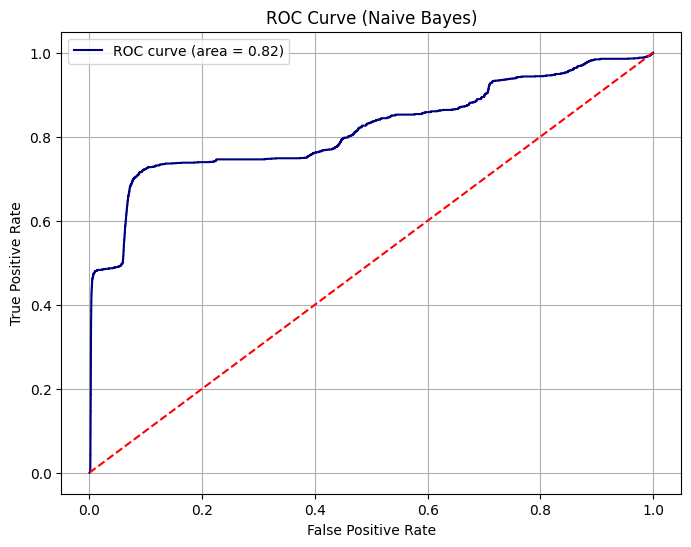

In [41]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Create sample weights for Naive Bayes based on class imbalance
sample_weights_nb = np.array([class_weights_dict[label] for label in y_train])

# Initialize Gaussian Naive Bayes model
nb_model = GaussianNB()

print("Training Naive Bayes model... ")

# Train the model with sample weights
nb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights_nb)

print("Naive Bayes model trained.")

# Make predictions on the scaled validation set
y_pred_nb = nb_model.predict(X_valid_scaled)
y_pred_proba_nb = nb_model.predict_proba(X_valid_scaled)[:, 1]

# Evaluation
print("\nClassification Report (Naive Bayes):")
print(classification_report(y_valid, y_pred_nb))

print("\nConfusion Matrix (Naive Bayes):")
conf_matrix_nb = confusion_matrix(y_valid, y_pred_nb)
display(pd.DataFrame(conf_matrix_nb,
                     index=['Actual 0', 'Actual 1'],
                     columns=['Predicted 0', 'Predicted 1']))

roc_auc_nb = roc_auc_score(y_valid, y_pred_proba_nb)
print(f"\nROC AUC Score (Naive Bayes): {roc_auc_nb:.4f}")

# Plot ROC curve
fpr_nb, tpr_nb, _ = roc_curve(y_valid, y_pred_proba_nb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, color='navy', label=f'ROC curve (area = {roc_auc_nb:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Naive Bayes)')
plt.legend()
plt.grid(True)
plt.show()

### Random Forest Classifier Model

Training Random Forest model...

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257815
           1       0.26      0.93      0.41      1520

    accuracy                           0.98    259335
   macro avg       0.63      0.96      0.70    259335
weighted avg       1.00      0.98      0.99    259335

ROC AUC Score: 0.9956


,Predicted 0,Predicted 1
Actual 0,253850,3965
Actual 1,106,1414


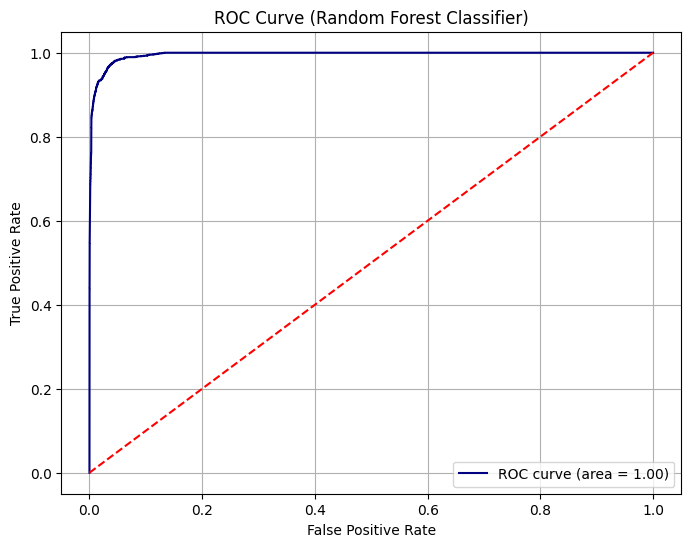

In [48]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
# We use class_weight='balanced' to handle the fraud imbalance
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest model...")
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_valid)
y_pred_proba_rf = rf_model.predict_proba(X_valid)[:, 1]

print("\nClassification Report (Random Forest):")
print(classification_report(y_valid, y_pred_rf))
roc_auc_rf = roc_auc_score(y_valid, y_pred_proba_rf)
print(f"ROC AUC Score: {roc_auc_rf:.4f}")

conf_matrix_rf = confusion_matrix(y_valid, y_pred_rf)
display(pd.DataFrame(conf_matrix_rf,
                     index=['Actual 0', 'Actual 1'],
                     columns=['Predicted 0', 'Predicted 1']))
# Plot ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_valid, y_pred_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='navy', label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Random Forest Classifier)')
plt.legend()
plt.grid(True)
plt.show()

### LightGBM Classifier Model

Training LightGBM model...
[LightGBM] [Info] Number of positive: 7506, number of negative: 1289169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.171393 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 789
[LightGBM] [Info] Number of data points in the train set: 1296675, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005789 -> initscore=-5.146050
[LightGBM] [Info] Start training from score -5.146050

Classification Report (LightGBM):
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    257815
           1       0.10      0.96      0.19      1520

    accuracy                           0.95    259335
   macro avg       0.55      0.96      0.58    259335
weighted avg       0.99      0.95      0.97    259335

ROC AUC Score: 0.9541


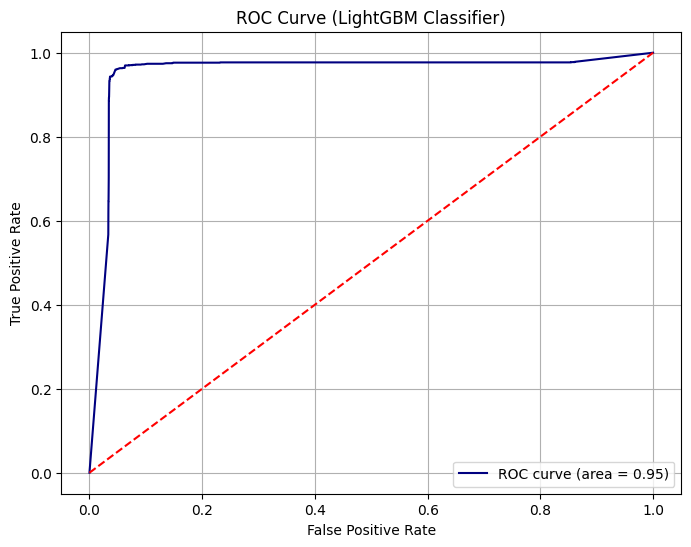

In [50]:
import lightgbm as lgb

# LightGBM handles imbalance using the 'is_unbalance' or 'scale_pos_weight' parameter
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1
)

print("Training LightGBM model...")
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_valid)
y_pred_proba_lgb = lgb_model.predict_proba(X_valid)[:, 1]
roc_auc_lgb = roc_auc_score(y_valid, y_pred_proba_lgb)
print("\nClassification Report (LightGBM):")
print(classification_report(y_valid, y_pred_lgb))
print(f"ROC AUC Score: {roc_auc_lgb:.4f}")
# Plot ROC curve
fpr_lgb, tpr_lgb, _ = roc_curve(y_valid, y_pred_proba_lgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, color='navy', label=f'ROC curve (area = {roc_auc_lgb:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (LightGBM Classifier)')
plt.legend()
plt.grid(True)
plt.show()

# **Model comparison**

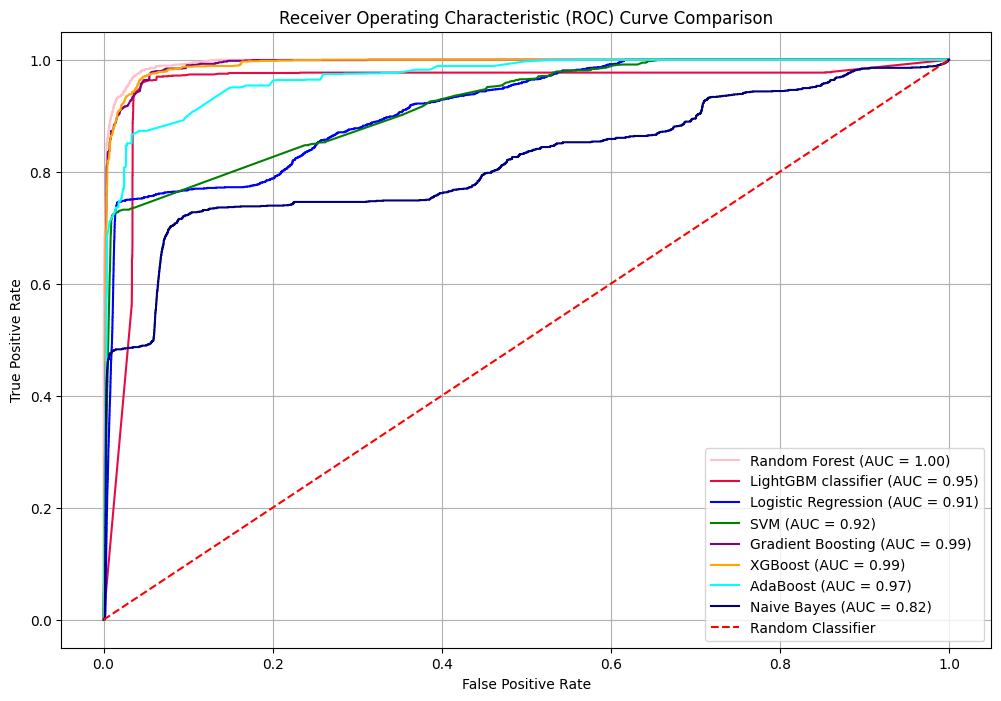

In [54]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# --- 1. Get ROC curve for Logistic Regression (if not already done) ---
# Assuming 'log_reg_model' is trained, and X_valid, y_valid are available.
# Predict probabilities for Logistic Regression
y_pred_proba_log_reg = log_reg_model.predict_proba(X_valid)[:, 1]

# Calculate ROC curve and AUC for Logistic Regression
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_valid, y_pred_proba_log_reg)
roc_auc_log_reg = roc_auc_score(y_valid, y_pred_proba_log_reg)

# --- 2. Plot all ROC curves on a single graph ---

plt.figure(figsize=(12, 8))
# Plot Random Forest Classifier
plt.plot(fpr_rf, tpr_rf, color='pink', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
# Plot LightGBM Classifier
plt.plot(fpr_lgb, tpr_lgb, color=(234/255, 10/255, 66/255), label=f'LightGBM classifier (AUC = {roc_auc_lgb:.2f})')
# Plot Logistic Regression ROC
plt.plot(fpr_log_reg, tpr_log_reg, color='blue', label=f'Logistic Regression (AUC = {roc_auc_log_reg:.2f})')

# Plot SVM ROC (assuming fpr_svm, tpr_svm, roc_auc_svm are available from previous cells)
plt.plot(fpr_svm, tpr_svm, color='green', label=f'SVM (AUC = {roc_auc_svm:.2f})')

# Plot Gradient Boosting ROC (assuming fpr_gbc, tpr_gbc, roc_auc_gbc are available)
plt.plot(fpr_gbc, tpr_gbc, color='purple', label=f'Gradient Boosting (AUC = {roc_auc_gbc:.2f})')

# Plot XGBoost ROC (assuming fpr_xgb, tpr_xgb, roc_auc_xgb are available)
plt.plot(fpr_xgb, tpr_xgb, color='orange', label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')

# Plot AdaBoost ROC (assuming fpr_ada, tpr_ada, roc_auc_ada are available)
plt.plot(fpr_ada, tpr_ada, color='cyan', label=f'AdaBoost (AUC = {roc_auc_ada:.2f})')

# Plot Naive Bayes ROC (assuming fpr_nb, tpr_nb, roc_auc_nb are available)
plt.plot(fpr_nb, tpr_nb, color='navy', label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# List of models and their names
models = [
    ('Logistic Regression', log_reg_model, X_valid),
    ('SVM', svm_model, X_valid_scaled),
    ('Gradient Boosting', gbc_model, X_valid_scaled),
    ('XGBoost', xgb_model, X_valid_scaled),
    ('AdaBoost', ada_model, X_valid_scaled),
    ('Naive Bayes', nb_model, X_valid_scaled),
    ('Random Forest', rf_model, X_valid),
    ('LightGBM', lgb_model, X_valid)
]

# Calculate metrics for each model
results = []
for name, model, X in models:
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_valid, y_pred),
        'Precision': precision_score(y_valid, y_pred),
        'Recall': recall_score(y_valid, y_pred),
        'F1-Score': f1_score(y_valid, y_pred),
        'ROC AUC': roc_auc_score(y_valid, y_prob)
    })

# Create Comparison DataFrame
df_comparison = pd.DataFrame(results)

# Display the results sorted by ROC AUC
display(df_comparison.sort_values(by='Recall', ascending=False).reset_index(drop=True))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,LightGBM,0.950446,0.102505,0.961184,0.185253,0.954133
1,XGBoost,0.959435,0.122166,0.957237,0.216679,0.992158
2,Gradient Boosting,0.957676,0.116421,0.944079,0.207280,0.992181
3,Random Forest,0.984302,0.262874,0.930263,0.409914,0.995567
4,AdaBoost,0.948538,0.091644,0.873026,0.165875,0.970087
5,Logistic Regression,0.892425,0.040741,0.769737,0.077386,0.914070
6,Naive Bayes,0.611830,0.011298,0.753947,0.022262,0.817607
7,SVM,0.994139,0.000000,0.000000,0.000000,0.918677


Fine tuning of the choosen model - XGBoost

In [59]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

# Using y_pred_proba_xgb for the XGBoost model and y_valid for the actual labels
for threshold in np.arange(0.1, 1.0, 0.1):
    temp_preds = (y_pred_proba_xgb >= threshold).astype(int)
    p = precision_score(y_valid, temp_preds)
    r = recall_score(y_valid, temp_preds)
    print(f"Threshold: {threshold:.1f} | Precision: {p:.2f} | Recall: {r:.2f}")

Threshold: 0.1 | Precision: 0.03 | Recall: 1.00
Threshold: 0.2 | Precision: 0.04 | Recall: 0.99
Threshold: 0.3 | Precision: 0.06 | Recall: 0.98
Threshold: 0.4 | Precision: 0.09 | Recall: 0.97
Threshold: 0.5 | Precision: 0.12 | Recall: 0.96
Threshold: 0.6 | Precision: 0.20 | Recall: 0.92
Threshold: 0.7 | Precision: 0.31 | Recall: 0.88
Threshold: 0.8 | Precision: 0.39 | Recall: 0.85
Threshold: 0.9 | Precision: 0.45 | Recall: 0.82
